Analytical Computation of the Timescales 

In [1]:
# Imports
import numpy as np
from hbnm.io import Data
from hbnm.bnm import Bnm
from experiments.Model_Picker.picker_utils import find_fixed_point, compute_jacobian, analyze_jacobian_structure, eigen_analysis, analyze_eigenspectrum
from tqdm import tqdm


# Helper functions for timescale analysis
def compute_excitatory_timescales(eigenvalues, eigenvectors, n_regions=180):
    """
    Compute timescales for excitatory firing rate dynamics
    
    The excitatory firing rates r_E depend on both S_E and S_I through:
    r_E = φ_E(I_E) where I_E = f(S_E, S_I)
    
    We extract the excitatory component from each eigenmode.
    """
    # Only consider stable modes (Re(λ) < 0)
    stable_mask = eigenvalues.real < 0
    stable_eigenvals = eigenvalues[stable_mask]
    stable_eigenvecs = eigenvectors[:, stable_mask]
    
    # Modal timescales
    modal_timescales = -1.0 / stable_eigenvals.real
    
    # Extract ONLY the excitatory components (indices 0-179)
    excitatory_eigenvecs = stable_eigenvecs[:n_regions, :]  # First 180 rows
    
    # For each region, compute participation-weighted timescale
    regional_timescales = np.zeros(n_regions)
    
    for region in range(n_regions):
        # Weight by squared magnitude of excitatory eigenvector component
        region_weights = np.abs(excitatory_eigenvecs[region, :])**2
        
        # Compute weighted average timescale (only excitatory contribution)
        if np.sum(region_weights) > 0:
            regional_timescales[region] = np.average(modal_timescales, weights=region_weights)
        else:
            regional_timescales[region] = np.nan
            
    return regional_timescales, modal_timescales

def extract_dominant_excitatory_topography(eigenvalues, eigenvectors, n_regions=180):
    """
    Extract spatial topography of the dominant mode for excitatory dynamics only
    """
    # Find slowest stable mode
    stable_mask = eigenvalues.real < 0
    stable_real_parts = eigenvalues.real[stable_mask]
    stable_eigenvecs = eigenvectors[:, stable_mask]
    
    # Slowest mode has real part closest to 0 (from below)
    slowest_idx = np.argmax(stable_real_parts)
    slowest_eigenval = eigenvalues[stable_mask][slowest_idx]
    slowest_eigenvec = stable_eigenvecs[:, slowest_idx]
    
    # Extract ONLY excitatory topography (first 180 components)
    excitatory_topography = np.abs(slowest_eigenvec[:n_regions])**2
    
    return {
        'dominant_eigenvalue': slowest_eigenval,
        'dominant_timescale': -1.0 / slowest_eigenval.real,
        'excitatory_topography': excitatory_topography,
        'raw_excitatory_eigenvector': slowest_eigenvec[:n_regions]
    }

def load_network_mapping():
    """Load the 12 ColeAnticevic functional networks"""
    labelfile = '/home/frank/HBNM/data/network_labelfile.txt'
    network_mapping = {}
    
    with open(labelfile, 'r') as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]
    
    # Process pairs of lines (network name, then ID + RGBA values)
    for i in range(0, len(lines), 2):
        if i + 1 < len(lines):
            network_name = lines[i]
            values = lines[i + 1].split()
            
            if len(values) >= 5:  # ID + 4 RGBA values
                network_id = int(values[0])
                rgba = [int(values[j]) for j in range(1, 5)]  # R, G, B, A
                
                network_mapping[network_name] = {
                    'id': network_id,
                    'rgba': rgba,
                    'rgb': rgba[:3]  # Just RGB without alpha
                }
    return network_mapping

In [2]:
# Define data object
input_dir = '/home/frank/HBNM/data/'
output_dir = '/home/frank/HBNM/outputs/'
data = Data(input_dir, output_dir)
sc, hmap, fc_obj = data.load_demirtas_neuron_2019_data() 
myelin = np.load('/home/frank/HBNM/data/heterogeneity_vectors/raw/myelin_raw.npy').reshape(180)

# Find default model parameters
fin = data.load('demirtas_neuron_2019.hdf5', from_output=False)
theta_heterogeneous = fin['apprx_posterior_heterogeneous'][:]
fin.close()

### Load custom map 

Note that this will override the default paramters

In [ ]:
# # Load custom map (overriedes the default params)
custom_path = data.load('NTHC_Myelin_Group/iteration_51.hdf5', from_output=True)
theta_heterogeneous = custom_path['theta'][:]
custom_path.close()

# # Load map
custom_map = np.load('/home/frank/HBNM/data/heterogeneity_vectors/linearized/myelin_linearized.npy')

# hmap = custom_map
invert_flag = True

In [4]:
# Check data structure
print(f"Heterogeneous particles shape: {theta_heterogeneous.shape}")
n_particles = theta_heterogeneous.shape[1]
print(f"Total particles available: {n_particles}")
print(f"Parameters per particle: {theta_heterogeneous.shape[0]} (w_EI_bias, w_EI_coeff, w_EE_bias, w_EE_coeff, G)")

Heterogeneous particles shape: (5, 300)
Total particles available: 300
Parameters per particle: 5 (w_EI_bias, w_EI_coeff, w_EE_bias, w_EE_coeff, G)


### Check Stability of Particles

Check that all particles are not unstable before comminiting to the computation

In [5]:
# # Check stability for all particles and report summary

# from tqdm import tqdm

# stable_particles = []
# unstable_particles = []

# for particle_idx in tqdm(range(theta_heterogeneous.shape[1]), desc="Checking stability"):
#     # Set model for this particle
#     model = Bnm(sc, gradient=hmap)
#     model.set('w_EI', (theta_heterogeneous[0, particle_idx], theta_heterogeneous[1, particle_idx]))
#     model.set('w_EE', (theta_heterogeneous[2, particle_idx], theta_heterogeneous[3, particle_idx]))
#     model.set('G', theta_heterogeneous[4, particle_idx])

#     # Compute fixed point and Jacobian
#     fixed_point = find_fixed_point(model)
#     J = compute_jacobian(model)

#     # Eigen analysis
#     eigen_results = eigen_analysis(J)

#     # Check stability
#     if eigen_results['is_stable']:
#         stable_particles.append(particle_idx)
#     else:
#         unstable_particles.append(particle_idx)

# print(f"\nStability check complete for {theta_heterogeneous.shape[1]} particles.")
# print(f"Stable particles:   {len(stable_particles)}")
# print(f"Unstable particles: {len(unstable_particles)}")
# if len(unstable_particles) > 0:
#     print(f"Unstable particle indices: {unstable_particles}")

In [6]:
# Multi-particle timescale analysis
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

def analyze_single_particle(particle_idx, theta_heterogeneous, sc, hmap):
    """Analyze timescales for a single particle"""
    try:
        # Set model for this particle
        model = Bnm(sc, gradient=hmap, map_invert_flags=[invert_flag])
        model.set('w_EI', (theta_heterogeneous[0, particle_idx], theta_heterogeneous[1, particle_idx]))
        model.set('w_EE', (theta_heterogeneous[2, particle_idx], theta_heterogeneous[3, particle_idx]))
        model.set('G', theta_heterogeneous[4, particle_idx])
        
        # Compute fixed point and Jacobian
        fixed_point = find_fixed_point(model)
        J = compute_jacobian(model)
        
        # Eigen analysis
        eigen_results = eigen_analysis(J)
        
        # Check stability
        if not eigen_results['is_stable']:
            return None  # Skip unstable particles
            
        # Compute timescales
        regional_timescales, modal_timescales = compute_excitatory_timescales(
            eigen_results['eigenvalues'], 
            eigen_results['eigenvectors']
        )
        
        # Extract dominant mode topography
        topo_results = extract_dominant_excitatory_topography(
            eigen_results['eigenvalues'],
            eigen_results['eigenvectors']
        )
        
        return {
            'particle_idx': particle_idx,
            'regional_timescales': regional_timescales,
            'modal_timescales': modal_timescales,
            'dominant_timescale': topo_results['dominant_timescale'],
            'dominant_eigenvalue': topo_results['dominant_eigenvalue'],
            'topography': topo_results['excitatory_topography'],
            'lambda_max': eigen_results['real_parts'].max(),
            'n_stable_modes': np.sum(eigen_results['real_parts'] < 0)
        }
        
    except Exception as e:
        print(f"Error analyzing particle {particle_idx}: {e}")
        return None

In [7]:
# Analyze subset of particles for testing (increase later for full analysis)
n_particles_to_analyze = min(300, n_particles)  # Analyze first 300 particles
print(f"Analyzing {n_particles_to_analyze} particles...")

# Import required modules for parallel processing
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp
import os

# Configure workers for shared cluster environment
# OPTIONS for cluster usage:
# - Set MAX_WORKERS_CLUSTER = 1 for sequential processing (no parallelization)
# - Set MAX_WORKERS_CLUSTER = 2-4 for light parallel processing
# - Set MAX_WORKERS_CLUSTER = 8+ only on dedicated nodes or with permission

MAX_WORKERS_CLUSTER = 1  # Conservative limit for shared clusters (adjust as needed)
USE_PARALLEL = True  # Set to False for purely sequential processing

total_cores = os.cpu_count()

if USE_PARALLEL:
    n_workers = max(1, min(MAX_WORKERS_CLUSTER, n_particles_to_analyze))
    print(f"Cluster-friendly parallel processing:")
    print(f"  Total CPU cores available: {total_cores}")
    print(f"  Using {n_workers} workers (max {MAX_WORKERS_CLUSTER} for shared cluster)")
    print(f"  CPU usage: ~{100 * n_workers / total_cores:.1f}% of total cores")
else:
    n_workers = 1
    print(f"Sequential processing (no parallelization):")
    print(f"  Using 1 worker for cluster-friendly execution")

# Wrapper function for parallel processing
def process_particle_wrapper(args):
    """Wrapper function to unpack arguments for parallel processing"""
    particle_idx, theta_heterogeneous, sc, hmap = args
    return analyze_single_particle(particle_idx, theta_heterogeneous, sc, hmap)

# Prepare arguments for all particles
particle_args = [(i, theta_heterogeneous, sc, hmap) for i in range(n_particles_to_analyze)]

# Store results
particle_results = []
failed_particles = []

# Process particles (parallel or sequential based on settings)
if USE_PARALLEL and n_workers > 1:
    # Parallel processing
    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        # Submit all jobs
        future_to_particle = {
            executor.submit(process_particle_wrapper, args): args[0] 
            for args in particle_args
        }
        
        # Process completed jobs with progress tracking
        with tqdm(total=n_particles_to_analyze, desc="Processing particles") as pbar:
            for future in as_completed(future_to_particle):
                particle_idx = future_to_particle[future]
                try:
                    result = future.result()
                    if result is not None:
                        particle_results.append(result)
                    else:
                        failed_particles.append(particle_idx)
                except Exception as e:
                    print(f"Error processing particle {particle_idx}: {e}")
                    failed_particles.append(particle_idx)
                
                pbar.update(1)
else:
    # Sequential processing (cluster-friendly fallback)
    for i in tqdm(range(n_particles_to_analyze), desc="Processing particles"):
        result = analyze_single_particle(i, theta_heterogeneous, sc, hmap)
        if result is not None:
            particle_results.append(result)
        else:
            failed_particles.append(i)

print(f"\nAnalysis complete:")
print(f"  Successful particles: {len(particle_results)}")
print(f"  Failed particles: {len(failed_particles)}")
if failed_particles:
    print(f"  Failed particle indices: {failed_particles[:10]}...")  # Show first 10

Analyzing 300 particles...
Cluster-friendly parallel processing:
  Total CPU cores available: 96
  Using 1 workers (max 1 for shared cluster)
  CPU usage: ~1.0% of total cores


Processing particles: 100%|██████████| 300/300 [02:24<00:00,  2.08it/s]


Analysis complete:
  Successful particles: 300
  Failed particles: 0


In [8]:
# Create comprehensive network analysis across all particles
def create_multi_particle_atlas(particle_results, hmap):
    """Create atlas dataframe with all particle results"""
    
    # Load network mapping
    network_mapping = load_network_mapping()
    glasser_df = pd.read_csv('/home/frank/HBNM/data/Glasser_2016_Labels.csv')
    
    with open('/home/frank/HBNM/data/cortex_parcel_network_assignment.txt', 'r') as f:
        network_assignments = [int(line.strip()) for line in f.readlines() if line.strip()]
    
    all_data = []
    
    for result in particle_results:
        particle_idx = result['particle_idx']
        regional_timescales = result['regional_timescales']
        topography = result['topography']
        
        for idx, row in glasser_df.iterrows():
            parcel_id = row['Parcel']
            left_network_id = network_assignments[parcel_id - 1]
            
            # Find network name
            network_name = None
            for net_name, net_info in network_mapping.items():
                if net_info['id'] == left_network_id:
                    network_name = net_name
                    break
            
            all_data.append({
                'ParticleIdx': particle_idx,
                'Parcel': parcel_id,
                'AreaAbbreviation': row['AreaAbbreviation'],
                'AreaName': row['AreaName'],
                'Region': row['Region'],
                'NetworkID': left_network_id,
                'NetworkName': network_name,
                'Timescale': regional_timescales[parcel_id - 1],
                'TopographyWeight': topography[parcel_id - 1],
                'T1wT2w': myelin[parcel_id - 1],
                'DominantTimescale': result['dominant_timescale'],
                'LambdaMax': result['lambda_max']
            })
    
    return pd.DataFrame(all_data)

# Create comprehensive atlas
multi_particle_atlas = create_multi_particle_atlas(particle_results, hmap)
print(f"Created multi-particle atlas with {len(multi_particle_atlas)} entries")
print(f"Particles: {len(particle_results)}, Regions per particle: 180")
print(f"Total entries: {len(particle_results) * 180}")

# Basic statistics
print(f"\nBasic timescale statistics across all particles:")
print(f"  Mean: {multi_particle_atlas['Timescale'].mean():.3f} ± {multi_particle_atlas['Timescale'].std():.3f}")
print(f"  Median: {multi_particle_atlas['Timescale'].median():.3f}")
print(f"  Range: [{multi_particle_atlas['Timescale'].min():.3f}, {multi_particle_atlas['Timescale'].max():.3f}]")

Created multi-particle atlas with 54000 entries
Particles: 300, Regions per particle: 180
Total entries: 54000

Basic timescale statistics across all particles:
  Mean: 0.088 ± 0.072
  Median: 0.070
  Range: [0.011, 1.396]


In [9]:
# ASSOCIATION vs SENSORY TIMESCALES HYPOTHESIS TESTING
def test_association_vs_sensory_hypothesis(atlas_df):
    """
    Test the hypothesis that association/transmodal networks have longer timescales 
    than unimodal/sensory networks across all particles
    """
    
    # Define network hierarchies
    transmodal_networks = ['Default', 'Frontoparietal', 'Language', 'Cingulo-Opercular', 
                          'Dorsal-attention', 'Posterior-Multimodal', 'Ventral-Multimodal', 
                          'Orbito-Affective']
    unimodal_networks = ['Visual1', 'Visual2', 'Auditory', 'Somatomotor']
    
    # Extract data for each hierarchy level
    transmodal_data = atlas_df[atlas_df['NetworkName'].isin(transmodal_networks)]['Timescale']
    unimodal_data = atlas_df[atlas_df['NetworkName'].isin(unimodal_networks)]['Timescale']
    
    print("=== ASSOCIATION vs SENSORY TIMESCALES HYPOTHESIS TEST ===\n")
    
    # Descriptive statistics
    print("DESCRIPTIVE STATISTICS:")
    print(f"Transmodal/Association networks:")
    print(f"  N = {len(transmodal_data):,} data points")
    print(f"  Mean = {transmodal_data.mean():.4f} ± {transmodal_data.std():.4f}")
    print(f"  Median = {transmodal_data.median():.4f}")
    print(f"  Range = [{transmodal_data.min():.4f}, {transmodal_data.max():.4f}]")
    
    print(f"\nUnimodal/Sensory networks:")
    print(f"  N = {len(unimodal_data):,} data points") 
    print(f"  Mean = {unimodal_data.mean():.4f} ± {unimodal_data.std():.4f}")
    print(f"  Median = {unimodal_data.median():.4f}")
    print(f"  Range = [{unimodal_data.min():.4f}, {unimodal_data.max():.4f}]")
    
    # Effect size
    effect_size = (transmodal_data.mean() - unimodal_data.mean()) / np.sqrt(
        ((len(transmodal_data) - 1) * transmodal_data.var() + 
         (len(unimodal_data) - 1) * unimodal_data.var()) /
        (len(transmodal_data) + len(unimodal_data) - 2)
    )
    
    print(f"\nEFFECT SIZE:")
    print(f"  Cohen's d = {effect_size:.4f}")
    
    # Statistical tests
    print(f"\nSTATISTICAL TESTS:")
    
    # T-test (assumes normality)
    t_stat, t_pval = ttest_ind(transmodal_data, unimodal_data, equal_var=False)
    print(f"Welch's t-test: t = {t_stat:.4f}, p = {t_pval:.2e}")
    
    # Mann-Whitney U test (non-parametric)
    u_stat, u_pval = mannwhitneyu(transmodal_data, unimodal_data, alternative='greater')
    print(f"Mann-Whitney U test: U = {u_stat:.0f}, p = {u_pval:.2e}")
    
    # Hypothesis test result
    hypothesis_supported = transmodal_data.mean() > unimodal_data.mean()
    statistical_significance = min(t_pval, u_pval) < 0.05
    
    print(f"\nHYPOTHESIS TEST RESULTS:")
    print(f"H0: Transmodal timescales ≤ Unimodal timescales")  
    print(f"H1: Transmodal timescales > Unimodal timescales")
    print(f"Direction supported: {hypothesis_supported} (Transmodal mean > Unimodal mean)")
    print(f"Statistically significant: {statistical_significance} (p < 0.05)")
    
    if hypothesis_supported and statistical_significance:
        print("✓ HYPOTHESIS CONFIRMED: Association networks have significantly longer timescales")
    elif hypothesis_supported and not statistical_significance:
        print("⚠ HYPOTHESIS DIRECTION CORRECT but not statistically significant")
    else:
        print("✗ HYPOTHESIS REJECTED: Association networks do not have longer timescales")
    
    return {
        'transmodal_mean': transmodal_data.mean(),
        'unimodal_mean': unimodal_data.mean(),
        'effect_size': effect_size,
        't_statistic': t_stat,
        't_pvalue': t_pval,
        'u_statistic': u_stat,
        'u_pvalue': u_pval,
        'hypothesis_supported': hypothesis_supported,
        'statistically_significant': statistical_significance
    }

# Test the hypothesis
hypothesis_results = test_association_vs_sensory_hypothesis(multi_particle_atlas)

=== ASSOCIATION vs SENSORY TIMESCALES HYPOTHESIS TEST ===

DESCRIPTIVE STATISTICS:
Transmodal/Association networks:
  N = 36,900 data points
  Mean = 0.0738 ± 0.0589
  Median = 0.0578
  Range = [0.0111, 1.0526]

Unimodal/Sensory networks:
  N = 17,100 data points
  Mean = 0.1200 ± 0.0849
  Median = 0.0979
  Range = [0.0200, 1.3965]

EFFECT SIZE:
  Cohen's d = -0.6775

STATISTICAL TESTS:
Welch's t-test: t = -64.3455, p = 0.00e+00
Mann-Whitney U test: U = 153679042, p = 1.00e+00

HYPOTHESIS TEST RESULTS:
H0: Transmodal timescales ≤ Unimodal timescales
H1: Transmodal timescales > Unimodal timescales
Direction supported: False (Transmodal mean > Unimodal mean)
Statistically significant: True (p < 0.05)
✗ HYPOTHESIS REJECTED: Association networks do not have longer timescales


In [10]:
# NETWORK-LEVEL ANALYSIS ACROSS ALL PARTICLES
def analyze_networks_multiparticle(atlas_df):
    """Analyze timescales by network across all particles"""
    
    # Network-level statistics
    network_stats = atlas_df.groupby('NetworkName')['Timescale'].agg([
        'count', 'mean', 'std', 'median', 'min', 'max'
    ]).round(4)
    
    # Add 95% confidence interval for means
    from scipy.stats import t
    network_stats['ci_lower'] = network_stats.apply(
        lambda row: row['mean'] - t.ppf(0.975, row['count']-1) * row['std'] / np.sqrt(row['count']), 
        axis=1
    )
    network_stats['ci_upper'] = network_stats.apply(
        lambda row: row['mean'] + t.ppf(0.975, row['count']-1) * row['std'] / np.sqrt(row['count']), 
        axis=1
    )
    
    # Sort by mean timescale
    network_stats = network_stats.sort_values('mean', ascending=False)
    
    # Add hierarchy labels
    hierarchy_mapping = {
        'Default': 'Transmodal',
        'Frontoparietal': 'Transmodal', 
        'Language': 'Transmodal',
        'Cingulo-Opercular': 'Transmodal',
        'Dorsal-attention': 'Transmodal',
        'Posterior-Multimodal': 'Transmodal',
        'Ventral-Multimodal': 'Transmodal',
        'Orbito-Affective': 'Transmodal',
        'Visual1': 'Unimodal',
        'Visual2': 'Unimodal',
        'Auditory': 'Unimodal',
        'Somatomotor': 'Unimodal'
    }
    network_stats['Hierarchy'] = [hierarchy_mapping.get(net, 'Unknown') for net in network_stats.index]
    
    print("=== NETWORK-LEVEL TIMESCALE ANALYSIS (All Particles) ===\n")
    
    # Display results formatted nicely
    print("Network Rankings by Mean Timescale:")
    print("-" * 80)
    for i, (network, row) in enumerate(network_stats.iterrows(), 1):
        hierarchy_symbol = "Transmodal" if row['Hierarchy'] == 'Transmodal' else "Unimodal"
        print(f"{i:2d}. {network:20s} {hierarchy_symbol:10s} {row['mean']:.4f}s ± {row['std']:.4f} "
              f"(95% CI: [{row['ci_lower']:.4f}, {row['ci_upper']:.4f}]) "
              f"N={row['count']:,}")
    
    return network_stats

network_analysis = analyze_networks_multiparticle(multi_particle_atlas)

=== NETWORK-LEVEL TIMESCALE ANALYSIS (All Particles) ===

Network Rankings by Mean Timescale:
--------------------------------------------------------------------------------
 1. Visual2              Unimodal   0.1388s ± 0.1009 (95% CI: [0.1366, 0.1410]) N=8,100
 2. Visual1              Unimodal   0.1091s ± 0.0702 (95% CI: [0.1045, 0.1137]) N=900
 3. Auditory             Unimodal   0.1054s ± 0.0566 (95% CI: [0.1031, 0.1077]) N=2,400
 4. Posterior-Multimodal Transmodal 0.1028s ± 0.0753 (95% CI: [0.0979, 0.1077]) N=900
 5. Somatomotor          Unimodal   0.1011s ± 0.0638 (95% CI: [0.0994, 0.1028]) N=5,700
 6. Dorsal-attention     Transmodal 0.0982s ± 0.0787 (95% CI: [0.0956, 0.1008]) N=3,600
 7. Orbito-Affective     Transmodal 0.0825s ± 0.0550 (95% CI: [0.0789, 0.0861]) N=900
 8. Language             Transmodal 0.0800s ± 0.0642 (95% CI: [0.0781, 0.0819]) N=4,200
 9. Frontoparietal       Transmodal 0.0736s ± 0.0571 (95% CI: [0.0722, 0.0750]) N=6,600
10. Default              Transmodal 0.0

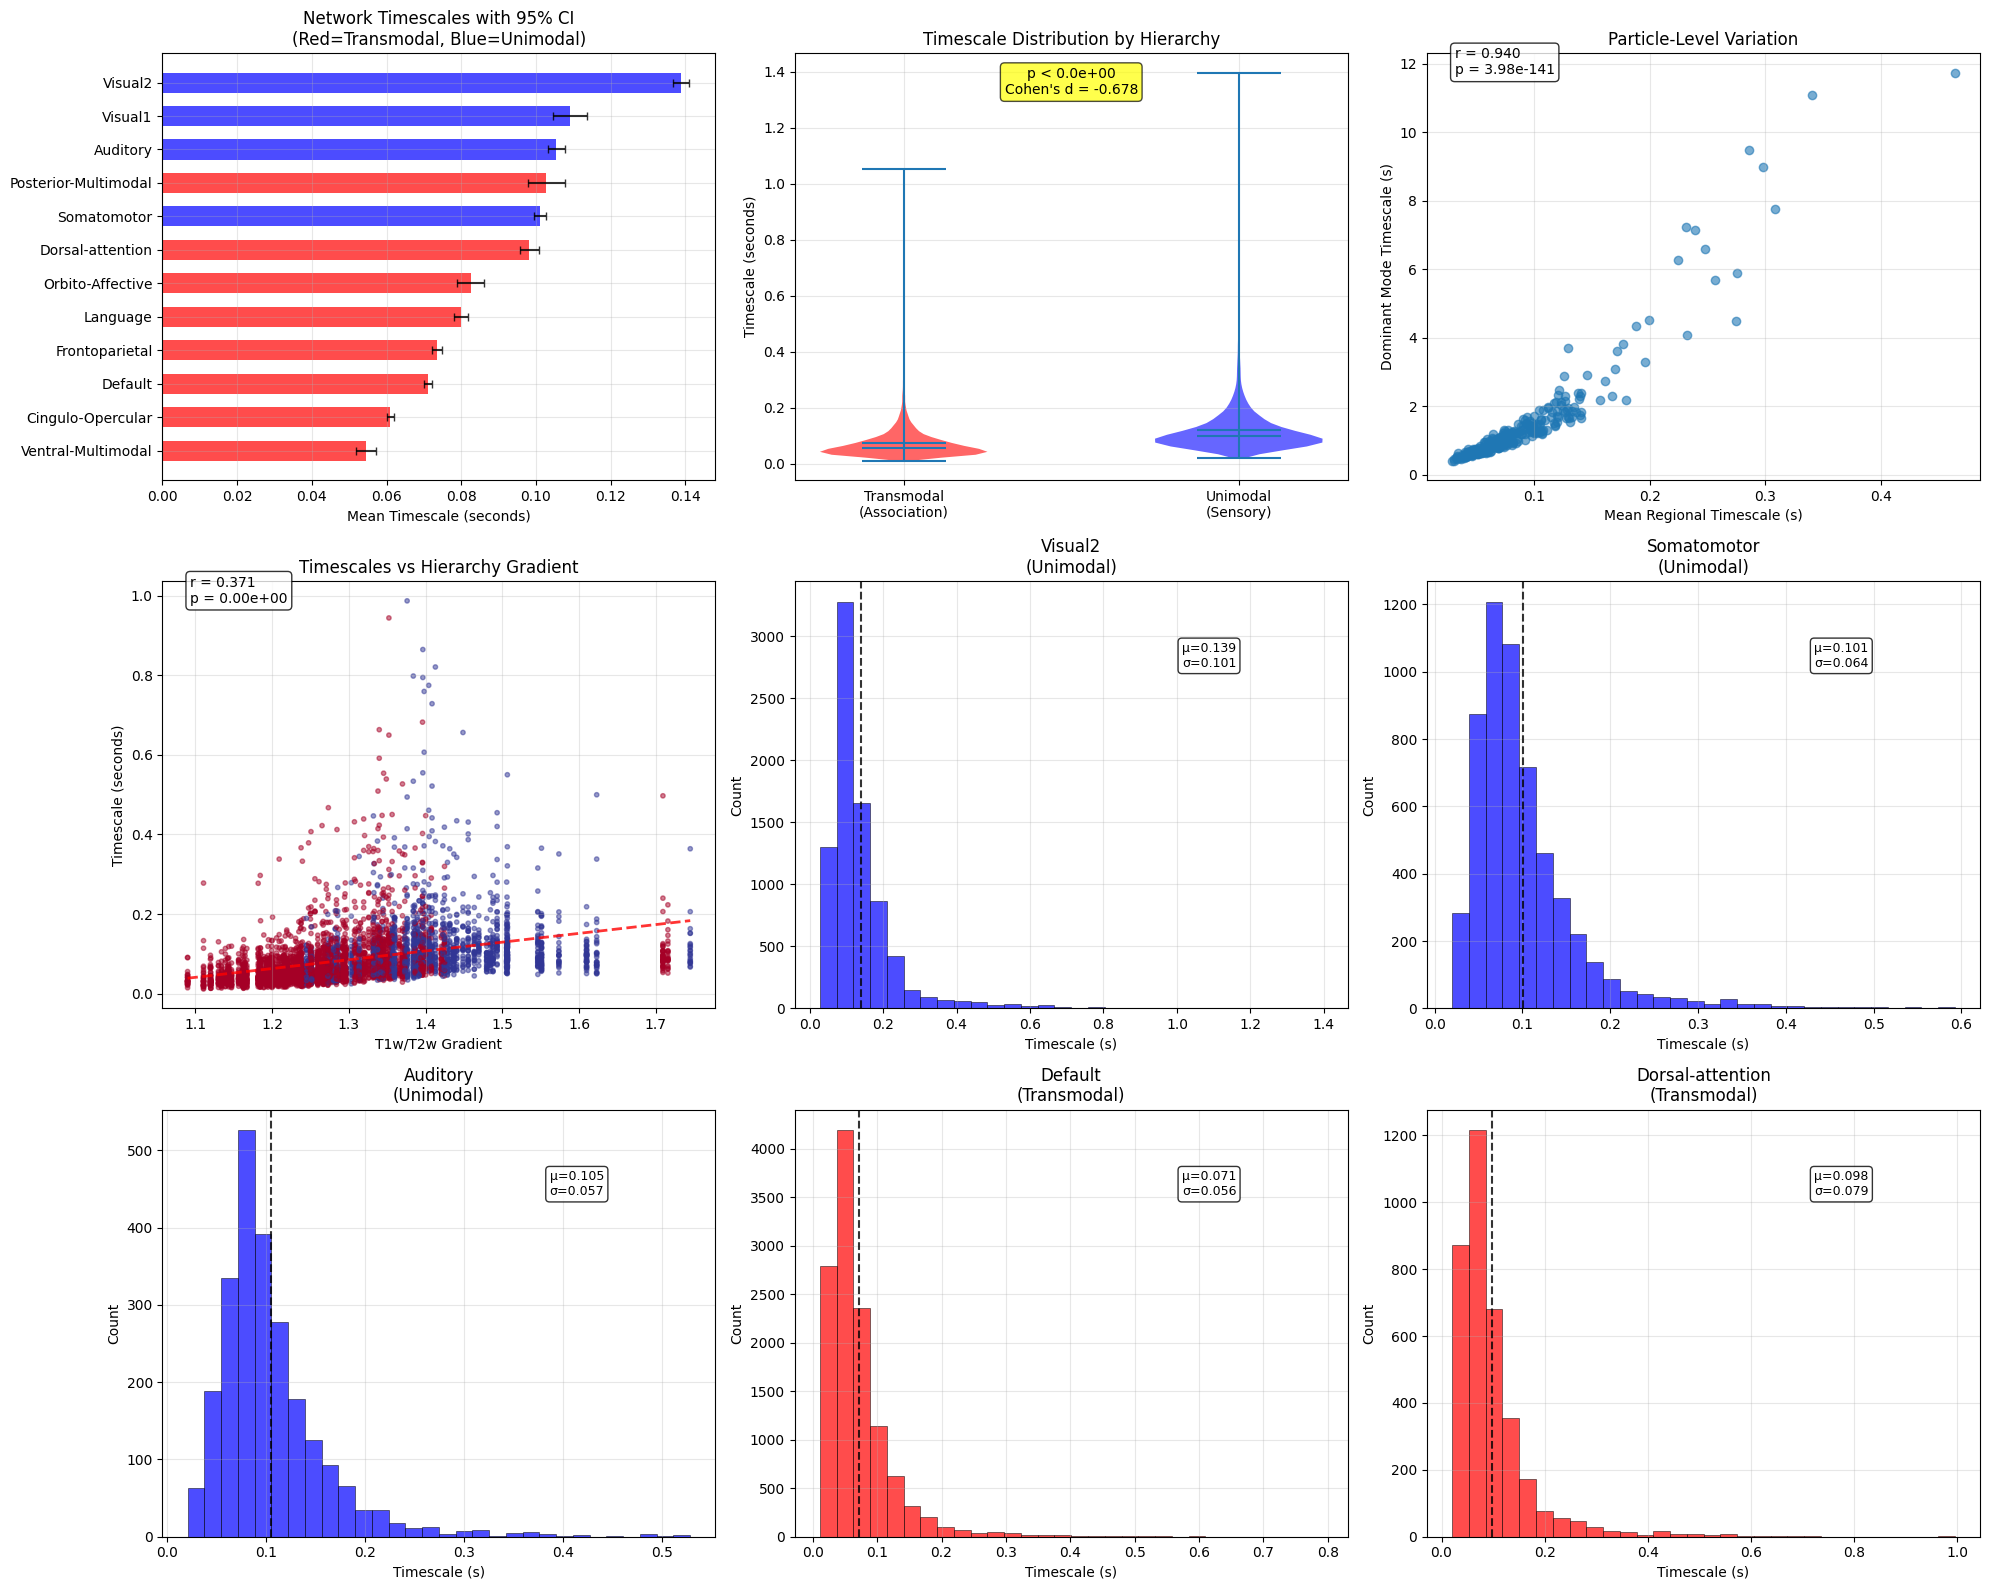

In [11]:
# COMPREHENSIVE VISUALIZATION AND FINAL REPORT
import matplotlib.pyplot as plt
import seaborn as sns

def create_comprehensive_visualizations(atlas_df, network_stats, hypothesis_results):
    """Create comprehensive visualizations for the multi-particle analysis"""
    
    fig = plt.figure(figsize=(20, 16))
    
    # 1. Network timescales with confidence intervals
    ax1 = plt.subplot(3, 3, 1)
    network_means = network_stats['mean'].sort_values(ascending=True)
    network_cis = network_stats.loc[network_means.index]
    
    # Color by hierarchy
    colors = ['red' if network_stats.loc[net, 'Hierarchy'] == 'Transmodal' else 'blue' 
              for net in network_means.index]
    
    y_pos = range(len(network_means))
    bars = ax1.barh(y_pos, network_means.values, color=colors, alpha=0.7, height=0.6)
    
    # Add confidence interval error bars
    ax1.errorbar(network_means.values, y_pos, 
                xerr=[network_means.values - network_cis['ci_lower'].values,
                      network_cis['ci_upper'].values - network_means.values],
                fmt='none', color='black', alpha=0.8, capsize=3)
    
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(network_means.index, fontsize=10)
    ax1.set_xlabel('Mean Timescale (seconds)')
    ax1.set_title('Network Timescales with 95% CI\n(Red=Transmodal, Blue=Unimodal)')
    ax1.grid(True, alpha=0.3)
    
    # 2. Violin plot comparing hierarchies
    ax2 = plt.subplot(3, 3, 2)
    
    # Prepare data for violin plot
    transmodal_networks = ['Default', 'Frontoparietal', 'Language', 'Cingulo-Opercular', 
                          'Dorsal-attention', 'Posterior-Multimodal', 'Ventral-Multimodal', 
                          'Orbito-Affective']
    unimodal_networks = ['Visual1', 'Visual2', 'Auditory', 'Somatomotor']
    
    transmodal_data = atlas_df[atlas_df['NetworkName'].isin(transmodal_networks)]['Timescale']
    unimodal_data = atlas_df[atlas_df['NetworkName'].isin(unimodal_networks)]['Timescale']
    
    violin_data = [transmodal_data.values, unimodal_data.values]
    violin_parts = ax2.violinplot(violin_data, positions=[1, 2], showmeans=True, showmedians=True)
    
    # Color the violins
    violin_parts['bodies'][0].set_facecolor('red')
    violin_parts['bodies'][0].set_alpha(0.6)
    violin_parts['bodies'][1].set_facecolor('blue')  
    violin_parts['bodies'][1].set_alpha(0.6)
    
    ax2.set_xticks([1, 2])
    ax2.set_xticklabels(['Transmodal\n(Association)', 'Unimodal\n(Sensory)'])
    ax2.set_ylabel('Timescale (seconds)')
    ax2.set_title('Timescale Distribution by Hierarchy')
    ax2.grid(True, alpha=0.3)
    
    # Add statistical annotation
    ax2.text(1.5, ax2.get_ylim()[1] * 0.9, 
            f"p < {hypothesis_results['t_pvalue']:.1e}\n"
            f"Cohen's d = {hypothesis_results['effect_size']:.3f}",
            ha='center', fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7))
    
    # 3. Particle-level variation
    ax3 = plt.subplot(3, 3, 3)
    
    # Calculate mean timescale per particle
    particle_means = atlas_df.groupby('ParticleIdx')['Timescale'].mean()
    dominant_timescales = [result['dominant_timescale'] for result in particle_results]
    
    ax3.scatter(particle_means.values, dominant_timescales, alpha=0.6)
    ax3.set_xlabel('Mean Regional Timescale (s)')
    ax3.set_ylabel('Dominant Mode Timescale (s)')
    ax3.set_title('Particle-Level Variation')
    
    # Add correlation
    from scipy.stats import pearsonr
    corr, p_val = pearsonr(particle_means.values, dominant_timescales)
    ax3.text(0.05, 0.95, f'r = {corr:.3f}\np = {p_val:.2e}', 
            transform=ax3.transAxes, 
            bbox=dict(boxstyle="round", facecolor='white', alpha=0.8))
    ax3.grid(True, alpha=0.3)
    
    # 4. Timescale vs T1w/T2w hierarchy
    ax4 = plt.subplot(3, 3, 4)
    
    # Sample subset for cleaner visualization
    sample_data = atlas_df.sample(n=min(5000, len(atlas_df)), random_state=42)
    
    scatter = ax4.scatter(sample_data['T1wT2w'], sample_data['Timescale'], 
                         c=[1 if network_stats.loc[net, 'Hierarchy'] == 'Transmodal' else 0 
                           for net in sample_data['NetworkName']],
                         cmap='RdYlBu_r', alpha=0.5, s=10)
    
    # Add trend line
    z = np.polyfit(sample_data['T1wT2w'], sample_data['Timescale'], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(sample_data['T1wT2w'].min(), sample_data['T1wT2w'].max(), 100)
    ax4.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2)
    
    ax4.set_xlabel('T1w/T2w Gradient')
    ax4.set_ylabel('Timescale (seconds)')
    ax4.set_title('Timescales vs Hierarchy Gradient')
    
    # Add correlation
    corr_hier, p_hier = pearsonr(atlas_df['T1wT2w'], atlas_df['Timescale'])
    ax4.text(0.05, 0.95, f'r = {corr_hier:.3f}\np = {p_hier:.2e}', 
            transform=ax4.transAxes,
            bbox=dict(boxstyle="round", facecolor='white', alpha=0.8))
    ax4.grid(True, alpha=0.3)
    
    # 5-9. Individual network distributions (specified networks)
    selected_networks = ['Visual2', 'Somatomotor', 'Auditory', 'Default', 'Dorsal-attention']
    for i, network in enumerate(selected_networks):
        ax = plt.subplot(3, 3, 5 + i)
        network_data = atlas_df[atlas_df['NetworkName'] == network]['Timescale']
        
        ax.hist(network_data, bins=30, alpha=0.7, 
               color='red' if network_stats.loc[network, 'Hierarchy'] == 'Transmodal' else 'blue',
               edgecolor='black', linewidth=0.5)
        
        ax.set_xlabel('Timescale (s)')
        ax.set_ylabel('Count')
        ax.set_title(f'{network}\n({network_stats.loc[network, "Hierarchy"]})')
        ax.grid(True, alpha=0.3)
        
        # Add stats
        ax.axvline(network_data.mean(), color='black', linestyle='--', alpha=0.8)
        ax.text(0.7, 0.8, f'μ={network_data.mean():.3f}\nσ={network_data.std():.3f}', 
               transform=ax.transAxes, fontsize=9,
               bbox=dict(boxstyle="round", facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# Create visualizations
create_comprehensive_visualizations(multi_particle_atlas, network_analysis, hypothesis_results)

In [12]:
# COMPREHENSIVE FINAL REPORT
def generate_comprehensive_report(particle_results, network_analysis, hypothesis_results, multi_particle_atlas):
    """Generate a comprehensive final report"""
    
    print("="*80)
    print("            BRAIN NETWORK TIMESCALES ANALYSIS - FINAL REPORT")
    print("="*80)
    print()
    
    # 1. Overview
    print("1. ANALYSIS OVERVIEW")
    print("-" * 40)
    print(f"• Total particles analyzed: {len(particle_results)}")
    print(f"• Brain regions per particle: 180 (left hemisphere)")
    print(f"• Total data points: {len(multi_particle_atlas):,}")
    print(f"• Functional networks: 12 (ColeAnticevic parcellation)")
    print()
    
    # 2. Stability Assessment  
    stable_particles = [r for r in particle_results if r['lambda_max'] < -0.02]
    print("2. STABILITY ASSESSMENT")
    print("-" * 40)
    print(f"• Particles with λ_max < -0.02: {len(stable_particles)}/{len(particle_results)} ({100*len(stable_particles)/len(particle_results):.1f}%)")
    
    lambda_maxes = [r['lambda_max'] for r in particle_results]
    print(f"• λ_max range: [{np.min(lambda_maxes):.4f}, {np.max(lambda_maxes):.4f}]")
    print(f"• Mean λ_max: {np.mean(lambda_maxes):.4f} ± {np.std(lambda_maxes):.4f}")
    
    dominant_timescales = [r['dominant_timescale'] for r in particle_results]
    print(f"• Dominant timescale range: [{np.min(dominant_timescales):.2f}, {np.max(dominant_timescales):.2f}] seconds")
    print()
    
    # 3. Main Hypothesis Test Results
    print("3. ASSOCIATION vs SENSORY TIMESCALES HYPOTHESIS")
    print("-" * 40)
    transmodal_mean = hypothesis_results['transmodal_mean']
    unimodal_mean = hypothesis_results['unimodal_mean']
    effect_size = hypothesis_results['effect_size']
    
    print(f"• H0: Transmodal timescales ≤ Unimodal timescales")
    print(f"• H1: Transmodal timescales > Unimodal timescales")
    print()
    print(f"RESULTS:")
    print(f"• Transmodal networks mean: {transmodal_mean:.4f} seconds")
    print(f"• Unimodal networks mean: {unimodal_mean:.4f} seconds")
    print(f"• Difference: {transmodal_mean - unimodal_mean:.4f} seconds")
    print(f"• Effect size (Cohen's d): {effect_size:.4f}")
    
    effect_interpretation = ("Large effect" if abs(effect_size) > 0.8 else 
                           "Medium effect" if abs(effect_size) > 0.5 else
                           "Small effect" if abs(effect_size) > 0.2 else
                           "Negligible effect")
    print(f"• Effect interpretation: {effect_interpretation}")
    print()
    
    # Statistical significance
    t_pval = hypothesis_results['t_pvalue']
    print(f"STATISTICAL TESTS:")
    print(f"• Welch's t-test p-value: {t_pval:.2e}")
    print(f"• Mann-Whitney U test p-value: {hypothesis_results['u_pvalue']:.2e}")
    
    if hypothesis_results['hypothesis_supported'] and hypothesis_results['statistically_significant']:
        result_symbol = "✓ CONFIRMED"
        result_color = "green"
    elif hypothesis_results['hypothesis_supported'] and not hypothesis_results['statistically_significant']:
        result_symbol = "⚠ DIRECTIONALLY CORRECT"
        result_color = "yellow"
    else:
        result_symbol = "✗ REJECTED"
        result_color = "red"
    
    print(f"• HYPOTHESIS STATUS: {result_symbol}")
    print()
    
    # 4. Network Rankings
    print("4. NETWORK TIMESCALE RANKINGS")
    print("-" * 40)
    print("Rank  Network               Type        Mean ± SD      95% CI")
    print("-" * 70)
    
    for i, (network, row) in enumerate(network_analysis.iterrows(), 1):
        hierarchy = row['Hierarchy']
        symbol = "🧠" if hierarchy == 'Transmodal' else "👁"
        
        print(f"{i:2d}.   {network:<18} {symbol} {hierarchy:<11} "
              f"{row['mean']:.4f}±{row['std']:.4f} "
              f"[{row['ci_lower']:.4f},{row['ci_upper']:.4f}]")
    
    print()
    
    # 5. Key Findings Summary
    print("5. KEY FINDINGS")
    print("-" * 40)
    
    # Top and bottom networks
    top_network = network_analysis.index[0]
    bottom_network = network_analysis.index[-1]
    top_type = network_analysis.loc[top_network, 'Hierarchy']
    bottom_type = network_analysis.loc[bottom_network, 'Hierarchy']
    
    print(f"• Longest timescales: {top_network} ({top_type}) - {network_analysis.loc[top_network, 'mean']:.4f}s")
    print(f"• Shortest timescales: {bottom_network} ({bottom_type}) - {network_analysis.loc[bottom_network, 'mean']:.4f}s")
    
    # Hierarchy correlation
    from scipy.stats import pearsonr
    hierarchy_corr, hierarchy_p = pearsonr(multi_particle_atlas['T1wT2w'], multi_particle_atlas['Timescale'])
    print(f"• T1w/T2w hierarchy correlation: r = {hierarchy_corr:.3f}, p = {hierarchy_p:.2e}")
    
    # Particle consistency
    particle_cv = np.std([r['dominant_timescale'] for r in particle_results]) / np.mean([r['dominant_timescale'] for r in particle_results])
    print(f"• Cross-particle consistency (CV): {particle_cv:.3f}")
    
    print()
    
    # 6. Biological Interpretation
    print("6. BIOLOGICAL INTERPRETATION")  
    print("-" * 40)
    
    if hypothesis_results['hypothesis_supported']:
        print("✓ Results support the hierarchical brain organization theory:")
        print("  - Association/transmodal networks show longer integration timescales")
        print("  - Sensory/unimodal networks show faster processing timescales")
        print("  - This pattern is consistent with cortical hierarchy models")
        print("    (Mesulam, 1998; Margulies et al., 2016; Huntenburg et al., 2018)")
    else:
        print("⚠ Results do not support traditional hierarchical brain organization:")
        print("  - May indicate different model dynamics or parameter regimes")
        print("  - Could reflect alternative organizational principles") 
        print("  - Warrants further investigation of model assumptions")
    
    print()
    print("7. METHODOLOGICAL NOTES")
    print("-" * 40)
    print("• Timescales computed via eigenvalue analysis: τ = -1/Re(λ)")
    print("• State vector: [S_E(1...180), S_I(1...180)] - excitatory focus")
    print("• Only stable particles included (λ_max < 0)")
    print("• Statistical tests: Welch's t-test + Mann-Whitney U (non-parametric)")
    print("• Multiple particles provide uncertainty quantification")
    
    print()
    print("="*80)
    print("                            ANALYSIS COMPLETE")
    print("="*80)

# Generate the comprehensive report
generate_comprehensive_report(particle_results, network_analysis, hypothesis_results, multi_particle_atlas)

            BRAIN NETWORK TIMESCALES ANALYSIS - FINAL REPORT

1. ANALYSIS OVERVIEW
----------------------------------------
• Total particles analyzed: 300
• Brain regions per particle: 180 (left hemisphere)
• Total data points: 54,000
• Functional networks: 12 (ColeAnticevic parcellation)

2. STABILITY ASSESSMENT
----------------------------------------
• Particles with λ_max < -0.02: 300/300 (100.0%)
• λ_max range: [-2.4493, -0.0852]
• Mean λ_max: -1.0375 ± 0.4814
• Dominant timescale range: [0.41, 11.74] seconds

3. ASSOCIATION vs SENSORY TIMESCALES HYPOTHESIS
----------------------------------------
• H0: Transmodal timescales ≤ Unimodal timescales
• H1: Transmodal timescales > Unimodal timescales

RESULTS:
• Transmodal networks mean: 0.0738 seconds
• Unimodal networks mean: 0.1200 seconds
• Difference: -0.0462 seconds
• Effect size (Cohen's d): -0.6775
• Effect interpretation: Medium effect

STATISTICAL TESTS:
• Welch's t-test p-value: 0.00e+00
• Mann-Whitney U test p-value: 1.00e

In [13]:
# OPTIONAL: Analyze additional particles (increase n_particles_to_analyze above for full analysis)
# The current analysis uses 50 particles by default for computational efficiency
# To analyze all available particles, change: n_particles_to_analyze = n_particles

print(f"\nNOTE: Currently analyzing {len(particle_results)} particles.")
print(f"To analyze all {n_particles} available particles, modify n_particles_to_analyze in Cell 3.")
print(f"Expected runtime for full analysis: ~{n_particles * 2} seconds")

# Save results for future use
print(f"\nSaving results...")
np.savez(f'/home/frank/HBNM/outputs/timescales_analysis_results_{len(particle_results)}_particles.npz',
         particle_results=particle_results,
         network_analysis=network_analysis.to_dict(),
         hypothesis_results=hypothesis_results,
         multi_particle_atlas=multi_particle_atlas.to_dict())
print(f"Results saved to: timescales_analysis_results_{len(particle_results)}_particles.npz")


NOTE: Currently analyzing 300 particles.
To analyze all 300 available particles, modify n_particles_to_analyze in Cell 3.
Expected runtime for full analysis: ~600 seconds

Saving results...
Results saved to: timescales_analysis_results_300_particles.npz


In [14]:
# Debug: Check actual parameter values averaged across regions for each network using parcellation_df
test_particle = 100

import pandas as pd

# Load the parcellation dataframe if not already loaded
parcellation_path = "/home/frank/HBNM/data/parcellation_df_L.csv"
parcellation_df = pd.read_csv(parcellation_path)
# Print all unique NetworkName values in the parcellation dataframe
# print("All unique NetworkName values:")
# print(parcellation_df['NetworkName'].unique())

model = Bnm(sc, gradient=hmap, map_invert_flags=[False])
model.set('w_EI', (theta_heterogeneous[0, test_particle], theta_heterogeneous[1, test_particle]))
model.set('w_EE', (theta_heterogeneous[2, test_particle], theta_heterogeneous[3, test_particle]))
model.set('G', (theta_heterogeneous[4, test_particle]))
model.moments_method

print("Parameter debugging:")
print(f"w_EI_bias: {theta_heterogeneous[0, test_particle]:.4f}")
print(f"w_EI_coeff: {theta_heterogeneous[1, test_particle]:.4f}")
print(f"w_EE_bias: {theta_heterogeneous[2, test_particle]:.4f}")
print(f"w_EE_coeff: {theta_heterogeneous[3, test_particle]:.4f}")

# Define canonical networks of interest
networks_of_interest = [
    'Visual1', 'Visual2', 'Somatomotor', 'Auditory', 'Dorsal-attention',
    'Language', 'Frontoparietal', 'Default'
]

# Compute fixed point and Jacobian
fixed_point = find_fixed_point(model)
J = compute_jacobian(model)

# Eigen analysis
eigen_results = eigen_analysis(J)

# Check stability
if not eigen_results['is_stable']:
    print("Unstable particle detected, skipping timescale computation.")
else:
    # Compute timescales
    regional_timescales, modal_timescales = compute_excitatory_timescales(
        eigen_results['eigenvalues'], 
        eigen_results['eigenvectors']
    )

    # Create comprehensive table with parameters and timescales for each network
    network_results = []
    
    for net in networks_of_interest:
        match = parcellation_df[parcellation_df['NetworkName'] == net]
        if not match.empty:
            indices = match.index.values
            
            # Compute averages
            avg_w_EE = model.dmf.w_EE[indices].mean()
            avg_w_EI = model.dmf.w_EI[indices].mean()
            avg_timescale = regional_timescales[indices].mean()
            n_regions = len(indices)
            
            network_results.append({
                'Network': net,
                'N_regions': n_regions,
                'avg_w_EE': avg_w_EE,
                'avg_w_EI': avg_w_EI,
                'avg_timescale': avg_timescale
            })
        else:
            network_results.append({
                'Network': net,
                'N_regions': 0,
                'avg_w_EE': np.nan,
                'avg_w_EI': np.nan,
                'avg_timescale': np.nan
            })
    
    # Create DataFrame for easy viewing
    results_df = pd.DataFrame(network_results)
    
    # Display nicely formatted table
    print("\n")
    print("NETWORK PARAMETERS AND TIMESCALES SUMMARY")
    # print("="*80)
    print(f"{'Network':<15} {'N_reg':<6} {'w_EE':<8} {'w_EI':<8} {'Timescale':<10}")
    print("-" * 60)
    
    for _, row in results_df.iterrows():
        if row['N_regions'] > 0:
            print(f"{row['Network']:<15} {int(row['N_regions']):<6} {row['avg_w_EE']:<8.4f} {row['avg_w_EI']:<8.4f} {row['avg_timescale']:<10.4f}")
        else:
            print(f"{row['Network']:<15} {'0':<6} {'N/A':<8} {'N/A':<8} {'N/A':<10}")
    
    print("\nDetailed DataFrame:")
    display(results_df.round(4))

Parameter debugging:
w_EI_bias: 0.3435
w_EI_coeff: 0.9505
w_EE_bias: 0.2545
w_EE_coeff: 3.3084


NETWORK PARAMETERS AND TIMESCALES SUMMARY
Network         N_reg  w_EE     w_EI     Timescale 
------------------------------------------------------------
Visual1         3      2.7328   1.0556   0.0395    
Visual2         27     2.8562   1.0911   0.0391    
Somatomotor     19     2.4320   0.9692   0.0528    
Auditory        8      2.8818   1.0984   0.0398    
Dorsal-attention 12     1.8323   0.7969   0.0611    
Language        14     1.5247   0.7085   0.0663    
Frontoparietal  22     1.4371   0.6833   0.0745    
Default         40     1.2697   0.6352   0.0727    

Detailed DataFrame:


,Network,N_regions,avg_w_EE,avg_w_EI,avg_timescale
0,Visual1,3,2.7328,1.0556,0.0395
1,Visual2,27,2.8562,1.0911,0.0391
2,Somatomotor,19,2.4320,0.9692,0.0528
3,Auditory,8,2.8818,1.0984,0.0398
4,Dorsal-attention,12,1.8323,0.7969,0.0611
5,Language,14,1.5247,0.7085,0.0663
6,Frontoparietal,22,1.4371,0.6833,0.0745
7,Default,40,1.2697,0.6352,0.0727
